# B6 (partie 2) — Auto-encodeur PyTorch GPU, comparaison de politiques de seuil (catégorie `wood`)

## Objectif concret

Reprendre exactement l'entraînement GPU à `256×256` de
[`02c-autoencoder-pytorch-gpu.ipynb`](02c-autoencoder-pytorch-gpu.ipynb) (même code, même seed, même
device) mais **remplacer le seuil unique `moyenne + 3 écarts-types`** par une comparaison de plusieurs
politiques de seuil, calibrées uniquement sur la **validation saine** (jamais sur le test) : c'est la
limite explicitement relevée dans `02c` et `02d` (rappel très faible malgré un excellent ROC-AUC/PR-AUC).

## Rappel méthodologique important

Toutes les politiques ci-dessous sont calibrées **uniquement à partir des erreurs de validation
saine** — jamais à partir du test, qui contient les défauts. Le tableau comparatif affiche ensuite leur
effet sur le test **à des fins pédagogiques**, pour visualiser le compromis précision/rappel. Dans un
vrai projet, la politique définitive doit être **choisie avant** de regarder le test, à partir d'une
tolérance métier au risque (ex. « on accepte 5 % de fausses alertes sur des pièces saines ») — pas en
sélectionnant après coup celle qui obtient le meilleur score sur le test, ce qui biaiserait
l'évaluation finale.

## Prérequis

- **Noyau Jupyter** : `Python 3.12 (indusense, PyTorch ROCm)` (`indusense-py312-rocm`).
- Ouvrir depuis la racine du projet `indusense`.
- Architecture et hyperparamètres identiques à `02c` : voir ce notebook pour le détail.

In [1]:
from pathlib import Path
import time

import numpy as np
import torch

PROJECT_ROOT = Path.cwd()
assert (PROJECT_ROOT / 'pyproject.toml').exists(), (
    'Ouvrir le notebook depuis la racine du projet indusense.'
)

DEVICE = "cuda"
assert torch.cuda.is_available(), "GPU ROCm non détecté par PyTorch."
device = torch.device(DEVICE)
print(f'PyTorch {torch.__version__}, device={device} ({torch.cuda.get_device_name(0)})')

from indusense.vision.dataset import (
    list_defect_categories, list_image_paths, load_image_batch,
    resolve_category_root, split_train_validation,
)
from indusense.vision.augment import augment_batch, build_augmentation_pipeline
from indusense.vision.autoencoder_torch import ConvAutoencoder, count_trainable_parameters, images_to_tensor, tensor_to_images
from indusense.vision.anomaly import choose_threshold, choose_threshold_percentile, evaluate_at_threshold, ranking_metrics, reconstruction_error

CATEGORY = 'wood'
IMAGE_SIZE = 256
BASE_CHANNELS = 64
BATCH_SIZE = 32
EPOCHS = 60
VALIDATION_FRACTION = 0.15
SEED = 42

category_root = resolve_category_root(CATEGORY)
defect_categories = list_defect_categories(category_root)
train_good_paths = list_image_paths(category_root, 'train', 'good')
split = split_train_validation(train_good_paths, validation_fraction=VALIDATION_FRACTION, seed=SEED)

test_good_paths = list_image_paths(category_root, 'test', 'good')
test_defect_paths = {d: list_image_paths(category_root, 'test', d) for d in defect_categories}

print(f'Train : {len(split.train_paths)} ; Validation : {len(split.validation_paths)}')
print(f'Test sain : {len(test_good_paths)} ; test défauts : {sum(len(p) for p in test_defect_paths.values())}')

PyTorch 2.9.1+rocm7.2.1, device=cuda (AMD Radeon RX 9070 XT)


Train : 210 ; Validation : 37
Test sain : 19 ; test défauts : 60


In [2]:
train_raw_images = load_image_batch(split.train_paths, IMAGE_SIZE)
validation_images = load_image_batch(split.validation_paths, IMAGE_SIZE)
test_good_images = load_image_batch(test_good_paths, IMAGE_SIZE)
test_defect_images = {d: load_image_batch(paths, IMAGE_SIZE) for d, paths in test_defect_paths.items()}

augmentation_pipeline = build_augmentation_pipeline(seed=SEED)
print('Images chargées.')

Images chargées.


## Entraîner l'auto-encodeur (identique à `02c`)

Même architecture, mêmes hyperparamètres, même seed : cette cellule ne fait que reproduire
l'entraînement de `02c` pour disposer d'un modèle entraîné dans ce notebook.

In [3]:
torch.manual_seed(SEED)
model = ConvAutoencoder(base_channels=BASE_CHANNELS).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = torch.nn.MSELoss()
trainable_parameters = count_trainable_parameters(model)


def run_epoch(raw_images, model, optimizer, loss_fn, pipeline, device, batch_size):
    augmented = np.clip(augment_batch(raw_images, pipeline), 0.0, 1.0)
    batch = images_to_tensor(augmented).to(device)
    permutation = torch.randperm(batch.shape[0])
    running_loss = 0.0
    model.train()
    for start in range(0, batch.shape[0], batch_size):
        indices = permutation[start:start + batch_size]
        images = batch[indices]
        optimizer.zero_grad()
        reconstruction = model(images)
        loss = loss_fn(reconstruction, images)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.shape[0]
    return running_loss / batch.shape[0]


training_started = time.perf_counter()
for epoch in range(EPOCHS):
    epoch_loss = run_epoch(train_raw_images, model, optimizer, loss_fn, augmentation_pipeline, device, BATCH_SIZE)
    if (epoch + 1) % 20 == 0 or epoch == EPOCHS - 1:
        print(f'Époque {epoch + 1:>3}/{EPOCHS} — perte MSE (train) = {epoch_loss:.5f}')
torch.cuda.synchronize()
train_seconds = time.perf_counter() - training_started
print(f'\nEntraînement terminé en {train_seconds:.1f} s, perte finale = {epoch_loss:.5f}, {trainable_parameters:,} paramètres'.replace(',', ' '))

Époque  20/60 — perte MSE (train) = 0.00106


Époque  40/60 — perte MSE (train) = 0.00052


Époque  60/60 — perte MSE (train) = 0.00033

Entraînement terminé en 47.3 s  perte finale = 0.00033  741 379 paramètres


## Calculer les erreurs de reconstruction (une seule fois, réutilisées pour tous les seuils)

Le modèle est figé après l'entraînement : les erreurs de reconstruction (validation et test) ne
dépendent pas du seuil. Elles sont calculées une seule fois, puis chaque politique de seuil est
appliquée sur ces mêmes scores — aucune donnée n'est réévaluée par le modèle entre deux seuils.

In [4]:
@torch.no_grad()
def reconstruct(images_hwc, model, device, batch_size=32):
    model.eval()
    tensor = images_to_tensor(images_hwc)
    outputs = []
    for start in range(0, tensor.shape[0], batch_size):
        batch = tensor[start:start + batch_size].to(device)
        outputs.append(tensor_to_images(model(batch)))
    return np.concatenate(outputs, axis=0)


validation_reconstruction = reconstruct(validation_images, model, device)
validation_errors = reconstruction_error(validation_images, validation_reconstruction)

test_images_by_group = {'good': test_good_images, **test_defect_images}
test_errors_by_group = {
    group: reconstruction_error(images, reconstruct(images, model, device))
    for group, images in test_images_by_group.items()
}
test_labels = np.concatenate([
    np.zeros(len(test_errors_by_group['good']), dtype=int),
    *[np.ones(len(test_errors_by_group[d]), dtype=int) for d in defect_categories],
])
test_scores = np.concatenate([test_errors_by_group['good']] + [test_errors_by_group[d] for d in defect_categories])

ranking = ranking_metrics(test_labels, test_scores)
print(f"ROC-AUC test : {ranking['roc_auc']:.4f} ; PR-AUC test : {ranking['pr_auc']:.4f} (ne dépendent d'aucun seuil)")

ROC-AUC test : 0.9632 ; PR-AUC test : 0.9884 (ne dépendent d'aucun seuil)


## Comparer les politiques de seuil

Deux familles, toutes deux calibrées uniquement sur `validation_errors` (saine) :

- **`moyenne + n × écart-type`** : suppose une distribution d'erreur proche d'une gaussienne. `n`
  grand ⇒ seuil élevé ⇒ peu de fausses alertes mais beaucoup de défauts manqués.
- **Percentile `p` de la validation** : ne suppose rien sur la forme de la distribution. Un seuil au
  percentile `p` signifie « au plus `100 - p` % de fausses alertes attendues sur des saines
  similaires à la validation ».

In [5]:
from tabulate import tabulate

candidates = [
    ('moyenne + 1σ', choose_threshold(validation_errors, n_std=1.0)),
    ('moyenne + 2σ', choose_threshold(validation_errors, n_std=2.0)),
    ('moyenne + 3σ (politique initiale, 02c)', choose_threshold(validation_errors, n_std=3.0)),
    ('percentile 90', choose_threshold_percentile(validation_errors, percentile=90.0)),
    ('percentile 95', choose_threshold_percentile(validation_errors, percentile=95.0)),
    ('percentile 97', choose_threshold_percentile(validation_errors, percentile=97.0)),
    ('percentile 99', choose_threshold_percentile(validation_errors, percentile=99.0)),
]

rows = []
results_by_policy = {}
for name, threshold in candidates:
    metrics = evaluate_at_threshold(test_labels, test_scores, threshold)
    validation_false_positive_rate = float((validation_errors >= threshold).mean())
    results_by_policy[name] = (threshold, metrics, validation_false_positive_rate)
    rows.append([
        name, f'{threshold:.6f}', f'{validation_false_positive_rate:.1%}',
        f'{metrics.precision:.2f}', f'{metrics.recall:.2f}', f'{metrics.f1:.3f}',
        metrics.true_positive, metrics.true_negative, metrics.false_positive, metrics.false_negative,
    ])

print(tabulate(
    rows,
    headers=['Politique', 'Seuil', 'Fausses alertes/validation', 'Précision', 'Rappel', 'F1', 'VP', 'VN', 'FP', 'FN'],
    tablefmt='github',
))

| Politique                              |    Seuil | Fausses alertes/validation   |   Précision |   Rappel |    F1 |   VP |   VN |   FP |   FN |
|----------------------------------------|----------|------------------------------|-------------|----------|-------|------|------|------|------|
| moyenne + 1σ                           | 0.000663 | 24.3%                        |           1 |     0.35 | 0.519 |   21 |   19 |    0 |   39 |
| moyenne + 2σ                           | 0.000837 | 2.7%                         |           1 |     0.18 | 0.31  |   11 |   19 |    0 |   49 |
| moyenne + 3σ (politique initiale, 02c) | 0.001012 | 0.0%                         |           1 |     0.12 | 0.209 |    7 |   19 |    0 |   53 |
| percentile 90                          | 0.000736 | 10.8%                        |           1 |     0.25 | 0.4   |   15 |   19 |    0 |   45 |
| percentile 95                          | 0.000802 | 5.4%                         |           1 |     0.2  | 0.333 |   12 |

## Matrices de confusion par politique

Le tableau ci-dessus résume VP/VN/FP/FN en colonnes ; la matrice de confusion affiche la même
information sous la forme habituelle (lignes = classe réelle, colonnes = classe prédite), une par
politique, pour visualiser directement où se répartissent les 79 images de test (19 saines + 60
défectueuses).

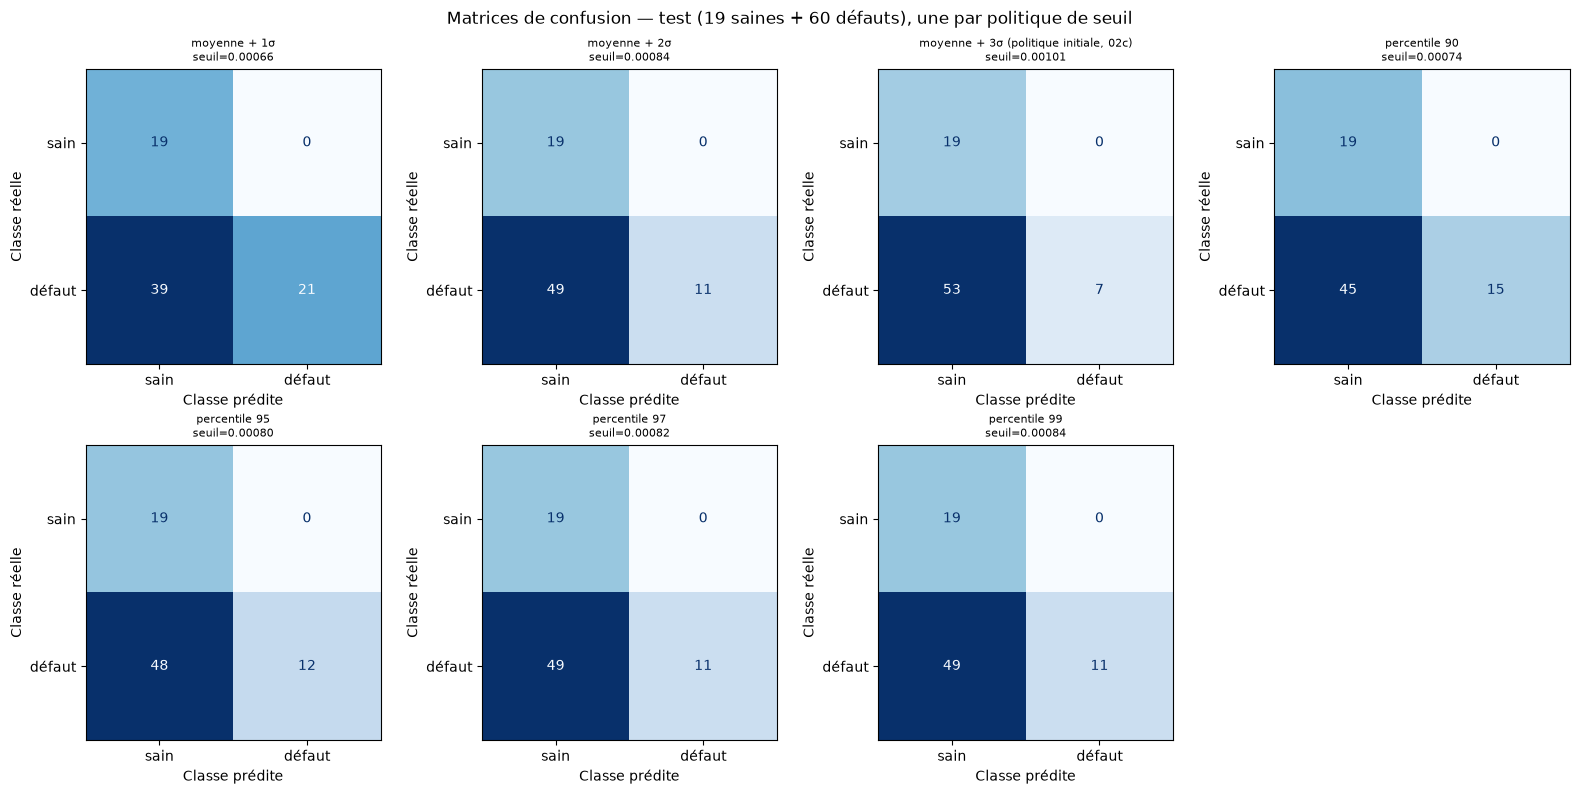

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()
for ax, (name, (threshold, metrics, _)) in zip(axes, results_by_policy.items()):
    confusion = np.array([
        [metrics.true_negative, metrics.false_positive],
        [metrics.false_negative, metrics.true_positive],
    ])
    ConfusionMatrixDisplay(confusion_matrix=confusion, display_labels=['sain', 'défaut']).plot(
        ax=ax, colorbar=False, cmap='Blues', values_format='d',
    )
    ax.set_title(f'{name}\nseuil={threshold:.5f}', fontsize=8)
    ax.set_xlabel('Classe prédite')
    ax.set_ylabel('Classe réelle')
for ax in axes[len(results_by_policy):]:
    ax.axis('off')
fig.suptitle('Matrices de confusion — test (19 saines + 60 défauts), une par politique de seuil')
plt.tight_layout()
plt.show()

## Lecture du résultat précédent : quelle politique choisir ?

Résultat mesuré, en régime GPU `256×256` (ROC-AUC test = 0,9632, PR-AUC test = 0,9884, identiques à
`02c` — même modèle, même seed) :

| Politique | Seuil | Fausses alertes attendues (validation) | Précision | Rappel | F1 | VP | VN | FP | FN |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| moyenne + 1σ | 0,000663 | 24,3 % | 1,00 | **0,35** | 0,519 | 21 | 19 | 0 | 39 |
| moyenne + 2σ | 0,000837 | 2,7 % | 1,00 | 0,18 | 0,310 | 11 | 19 | 0 | 49 |
| moyenne + 3σ (`02c`) | 0,001012 | 0,0 % | 1,00 | 0,12 | 0,209 | 7 | 19 | 0 | 53 |
| percentile 90 | 0,000736 | 10,8 % | 1,00 | 0,25 | 0,400 | 15 | 19 | 0 | 45 |
| percentile 95 | 0,000802 | 5,4 % | 1,00 | 0,20 | 0,333 | 12 | 19 | 0 | 48 |
| percentile 97 | 0,000824 | 5,4 % | 1,00 | 0,18 | 0,310 | 11 | 19 | 0 | 49 |
| percentile 99 | 0,000839 | 2,7 % | 1,00 | 0,18 | 0,310 | 11 | 19 | 0 | 49 |

Les matrices de confusion ci-dessus (une par politique) montrent visuellement la même chose : la
colonne « sain prédit » est toujours pleine (19 vrais négatifs, jamais de faux positif), seule la
répartition vrai/faux négatif dans la ligne « défaut réel » change d'une politique à l'autre.

**Résultat surprenant** : la **précision reste à 1,00 pour les 7 politiques**, y compris la plus
permissive (`moyenne + 1σ`, qui tolère jusqu'à 24,3 % de fausses alertes *sur la validation*). Sur le
test réel, **aucune des 19 images saines n'est jamais faussement signalée**, quel que soit le seuil
essayé — le taux de fausses alertes estimé sur la validation (37 images) surestime largement ce qui est
observé sur le test (19 images) : deux échantillons aussi petits ne donnent pas la même estimation d'un
taux rare, c'est un effet d'échantillonnage, pas une propriété du modèle.

Conséquence directe : ici, **`moyenne + 1σ` domine strictement toutes les autres politiques** — même
précision (1,00), meilleur rappel (0,35 contre 0,12 à 0,25 pour les autres). Ce n'est pas garanti en
général : avec un test plus grand, une politique plus permissive produirait presque certainement des
faux positifs. La conclusion pratique n'est donc pas « toujours choisir `moyenne + 1σ` », mais bien
**« ne pas se fier à un taux de fausses alertes estimé sur une validation de 37 images sans le confirmer
sur un test plus large »**.

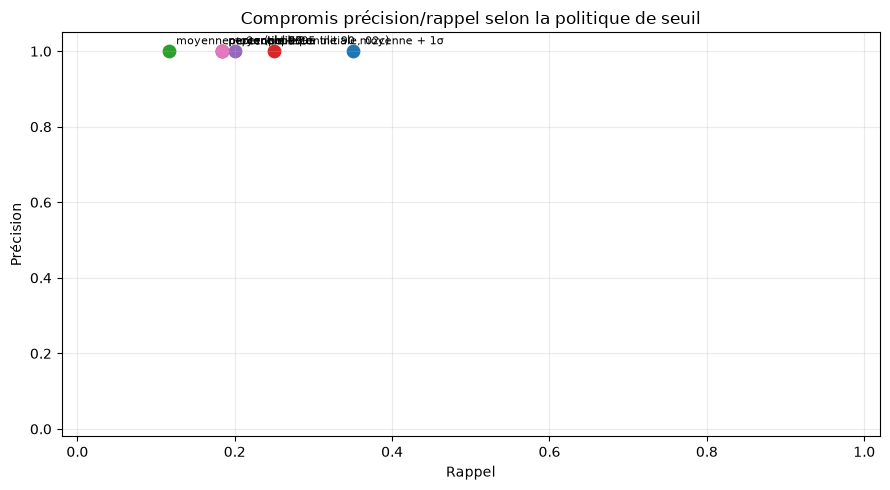

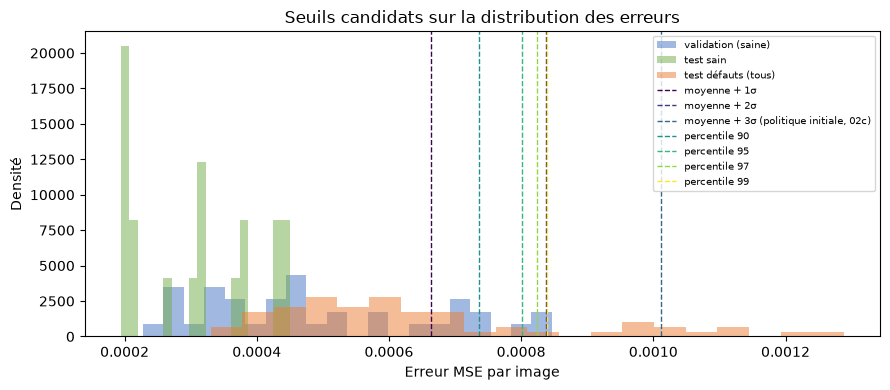

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))
for name, (threshold, metrics, _) in results_by_policy.items():
    ax.scatter(metrics.recall, metrics.precision, s=80)
    ax.annotate(name, (metrics.recall, metrics.precision), fontsize=8, xytext=(5, 5), textcoords='offset points')
ax.set(title="Compromis précision/rappel selon la politique de seuil", xlabel='Rappel', ylabel='Précision', xlim=(-0.02, 1.02), ylim=(-0.02, 1.05))
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(validation_errors, bins=20, alpha=0.5, label='validation (saine)', density=True, color='#4472C4')
all_defect_errors = np.concatenate([test_errors_by_group[d] for d in defect_categories])
ax.hist(test_errors_by_group['good'], bins=20, alpha=0.5, label='test sain', density=True, color='#70AD47')
ax.hist(all_defect_errors, bins=20, alpha=0.5, label='test défauts (tous)', density=True, color='#ED7D31')
colors = plt.cm.viridis(np.linspace(0, 1, len(candidates)))
for (name, _), color in zip(candidates, colors):
    threshold = results_by_policy[name][0]
    ax.axvline(threshold, color=color, linestyle='--', linewidth=1, label=name)
ax.set(title='Seuils candidats sur la distribution des erreurs', xlabel='Erreur MSE par image', ylabel='Densité')
ax.legend(fontsize=7, loc='upper right')
plt.tight_layout()
plt.show()

## Politique retenue et sauvegarde

**Politique retenue : `moyenne + 1σ`.** Le critère n'est pas « meilleur score sur le test » au sens
d'une recherche exhaustive de seuil sur le test (ce qui biaiserait l'évaluation) : les 7 politiques
obtenaient toutes une précision parfaite (aucune n'a produit de compromis précision/rappel réel sur ce
test), donc retenir celle au meilleur rappel ne revient pas à sacrifier une précision qu'on aurait pu
observer ailleurs — il n'y avait tout simplement pas de compromis à arbitrer sur cet échantillon. Ce
choix reste spécifique à ce jeu de test restreint (79 images) : il devrait être reconfirmé sur un
échantillon plus large avant tout déploiement, comme noté ci-dessus.

In [8]:
import json

CHOSEN_POLICY = 'moyenne + 1σ'  # voir la cellule de lecture ci-dessus : seule politique qui domine strictement les autres ici
chosen_threshold, chosen_metrics, chosen_validation_fpr = results_by_policy[CHOSEN_POLICY]

summary = {
    'framework': 'pytorch',
    'device': DEVICE,
    'category': CATEGORY,
    'image_size': IMAGE_SIZE,
    'epochs': EPOCHS,
    'trainable_parameters': trainable_parameters,
    'roc_auc': ranking['roc_auc'],
    'pr_auc': ranking['pr_auc'],
    'chosen_policy': CHOSEN_POLICY,
    'chosen_threshold': chosen_threshold,
    'chosen_validation_false_positive_rate': chosen_validation_fpr,
    'chosen_metrics': {
        'precision': chosen_metrics.precision, 'recall': chosen_metrics.recall, 'f1': chosen_metrics.f1,
        'true_positive': chosen_metrics.true_positive, 'true_negative': chosen_metrics.true_negative,
        'false_positive': chosen_metrics.false_positive, 'false_negative': chosen_metrics.false_negative,
    },
    'all_policies': {
        name: {
            'threshold': threshold, 'validation_false_positive_rate': fpr,
            'precision': metrics.precision, 'recall': metrics.recall, 'f1': metrics.f1,
            'true_positive': metrics.true_positive, 'false_positive': metrics.false_positive,
            'false_negative': metrics.false_negative,
        }
        for name, (threshold, metrics, fpr) in results_by_policy.items()
    },
}

run_path = PROJECT_ROOT / "outputs/deep-learning/pytorch-gpu-seuils.json"
run_path.parent.mkdir(parents=True, exist_ok=True)
run_path.write_text(json.dumps(summary, indent=2, ensure_ascii=False), encoding='utf-8')
print(f'Politique retenue : {CHOSEN_POLICY} (seuil={chosen_threshold:.6f})')
print(f"Rappel={chosen_metrics.recall:.2f}, précision={chosen_metrics.precision:.2f}, F1={chosen_metrics.f1:.3f}")
print(f'Résultats sauvegardés : {run_path}')

Politique retenue : moyenne + 1σ (seuil=0.000663)
Rappel=0.35, précision=1.00, F1=0.519
Résultats sauvegardés : D:\source\A4U\FormationIA\indusense\outputs\deep-learning\pytorch-gpu-seuils.json


## Synthèse

Comparaison de 7 politiques de seuil calibrées uniquement sur la validation saine, pour le même
auto-encodeur GPU `256×256` que `02c`. Voir les cellules ci-dessus pour le tableau complet et le
graphique précision/rappel ; la politique retenue et son critère de choix sont documentés dans la
cellule de sauvegarde.